In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
# 1. 데이터 생성 (랜덤 숫자 시퀀스)
data = np.array([i for i in range(1, 21)]) # 1부터 20까지의 숫자
timesteps = 3 # 타임 스텝 길이, sequence length와 같은 개념

In [3]:
x_data = []
y_data = []

In [4]:
# 타임스텝에 따라 입력 데이터와 출력 데이터 생성
for i in range(len(data)- timesteps):
    x_data.append(data[i:i + timesteps]) # 입력 (3개의 숫자)
    y_data.append(data[i + timesteps]) # 출력 (4번째 숫자)

x_data = np.array(x_data).reshape(-1, timesteps, 1) # (샘플 수, 타임 스텝, 피쳐 수)
y_data = np.array(y_data) # 출력값

In [5]:
# 2. LSTM 모델 정의
model = Sequential([
    LSTM(10, input_shape=(timesteps, 1)), # LSTM 레이어 (유닛 : 10)
    Dense(1) # 출력 레이어
])

d:\python_sim\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(optimizer='adam', loss='mse')

In [7]:
# 3. 모델 학습
model.fit(x_data, y_data, epochs=1000, verbose=1)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 174.1797
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 173.9496
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 173.7190
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 173.4876
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 173.2557
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 173.0230
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 172.7897
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 172.5556
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 172.3208
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 172.0851
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 171.8487
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 171.6113
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 171.3730
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 171.1338
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50m

In [8]:
# 4. 예측 테스트
test_input = np.array([18,19,20]).reshape(1, timesteps, 1) # 입력예시
predicted = model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


In [12]:
# 결과 출력
print(f"입력 데이터:", test_input.flatten())
print(f"예측 결과:", predicted[0][0])

입력 데이터: [18 19 20]
예측 결과: 12.821701


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [14]:
# 1. 데이터 로드
file_path = 'dataset/jena_climate_2009.csv'
data = pd.read_csv(file_path)

In [15]:
# 데이터 확인
# Date Time : 관측 날짜 및 시간. p (mbar) : 기압. T (degC) : 기온, Tpot (K) : 잠재온도
data.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [16]:
data.shape

(21743, 15)

In [17]:
# T (degC) : 기온
temperature = data['T (degC)'].values

In [18]:
# 2. 데이터 전처리
scaler = MinMaxScaler(feature_range=(0,1)) # 정규화
scaled_data = scaler.fit_transform(temperature.reshape(-1,1))

In [19]:
# 데이터셋 생성 함수 : look_back(sequence length와 같은 의미)
def create_dataset(dataset, look_back=60) :
    X, y = [], []
    for i in range(len(dataset) - look_back) :
        X.append(dataset[i:i+look_back, 0])
        y.append(dataset[i+look_back, 0])
    return np.array(X), np.array(y)

In [20]:
look_back = 60 # 과거 60분 데이터를 기반으로 예측
X, y = create_dataset(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # RNN 입력 형태

In [21]:
X.shape

(21683, 60, 1)

In [22]:
# 데이터 분리
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:] 


In [23]:
# 3. RNN 모델 정의
model = Sequential([
    SimpleRNN(50, return_sequences=False, input_shape=(X.shape[1], 1)), # 50(뉴런 즉 메모리유닛수), return_sequences=False(마지막 시점 출력만 반환)
    Dense(1)
])

d:\python_sim\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [25]:
# 4. 모델 학습
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0019 - val_loss: 3.3993e-04
Epoch 2/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.2297e-04 - val_loss: 2.5013e-04
Epoch 3/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 1.4959e-04 - val_loss: 1.2877e-04
Epoch 4/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.0152e-04 - val_loss: 1.7363e-04
Epoch 5/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 8.3320e-05 - val_loss: 1.8406e-04
Epoch 6/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7.0673e-05 - val_loss: 1.4704e-04
Epoch 7/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 6.3184e-05 - val_loss: 1.2004e-04
Epoch 8/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5.7005e-05 - val_loss: 1.3201e-04
Epoch 9/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.6035e-05 - val_loss: 9.0101e-05
Epoch 10/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5.2990e-05 - val_loss: 9.0426e-05
Epoch 11/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 4

In [26]:
# 5. 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions) # 정규화 복원

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [27]:
# 실제 값 복원
actual_values = scaler.inverse_transform(y_test.reshape(-1,1))

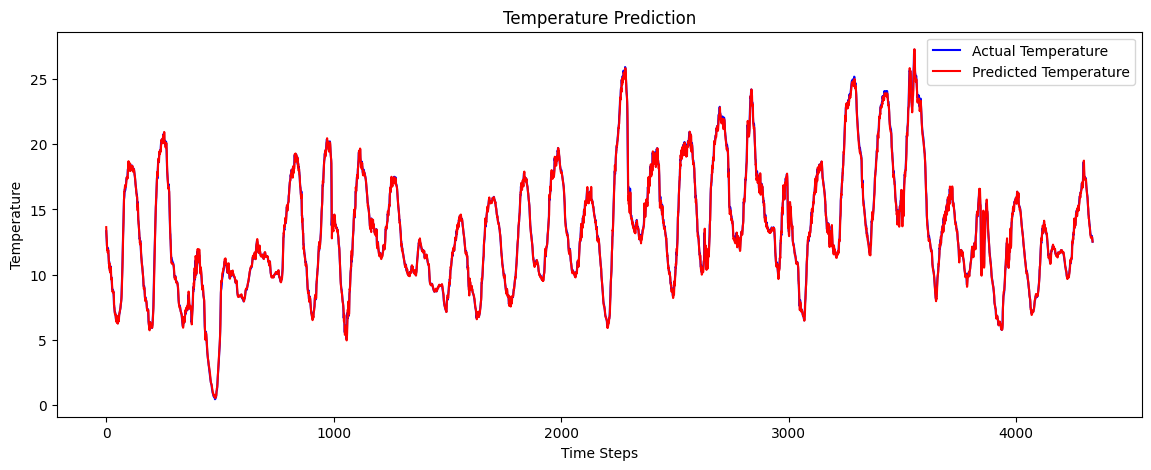

In [28]:
#6. 시각화
plt.figure(figsize=(14,5))
plt.plot(actual_values, label='Actual Temperature', color='blue')
plt.plot(predictions, label='Predicted Temperature', color='red')
plt.title('Temperature Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.legend()
plt.show()

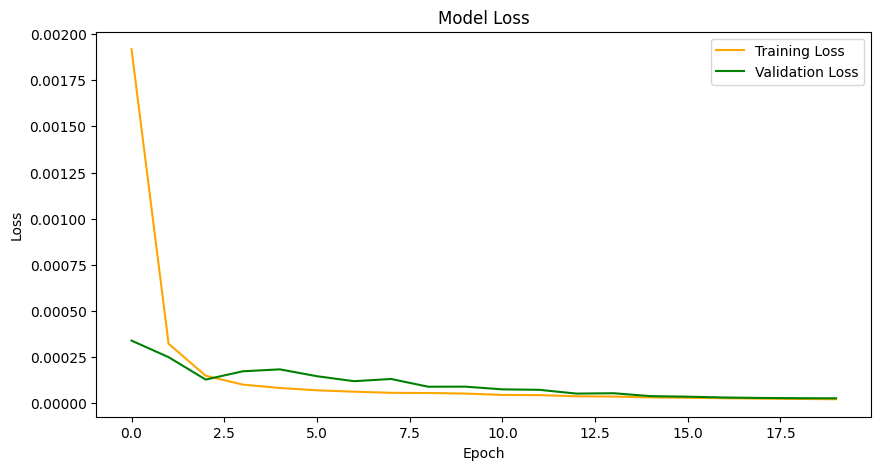

In [29]:
# 7. 학습 손실 시각화
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [30]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [31]:
# 1. 데이터 수집
ticker = "AAPL"  # 예 : 애플 주식
data = yf.download(ticker, start='2015-01-01', end='2024-01-01')
data = data[['Close']] # 종가만 사용

[*********************100%***********************]  1 of 1 completed


In [32]:
# 2. 데이터 전처리
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [33]:
def create_dataset(dataset, look_back=60) :
    X, y = [], []
    for i in range(len(dataset) - look_back) :
        X.append(dataset[i:i + look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [34]:
look_back = 60 # 과거 60일 데이터로 예측
X, y = create_dataset(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # LSTM 입력 형태 (샘플 수, 시퀀스 길이, 피쳐수)

In [36]:
# 3. 모델 구성
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)), # input_shape=(시퀀스 길이, 피처 수)
    LSTM(32, return_sequences=False),
    Dense(1) # 출력 레이어
])


In [37]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [38]:
# 4. 모델 학습
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [44]:
model.fit(X_train, y_train, epochs=11, batch_size=32, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 2.1990e-04 - val_loss: 4.5820e-04
Epoch 2/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 2.1568e-04 - val_loss: 4.4627e-04
Epoch 3/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.1318e-04 - val_loss: 4.4338e-04
Epoch 4/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.2069e-04 - val_loss: 4.5359e-04
Epoch 5/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.4148e-04 - val_loss: 4.8594e-04
Epoch 6/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.9269e-04 - val_loss: 5.7286e-04
Epoch 7/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.0443e-04 - val_loss: 9.5298e-04
Epoch 8/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 5.4244e-04 - val_loss: 0.0019
Epoch 9/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 5.2281e-04 - val_loss: 0.0011
Epoch 10/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.5664e-04 - val_loss: 4.4888e-04
Epoch 11/11
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.3819e-04 - val_

In [40]:
# 5. 예측 및 시각화
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1)) # 2차원 배열로 표시 (샘플수, 1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [41]:
# 실제 값 복원
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

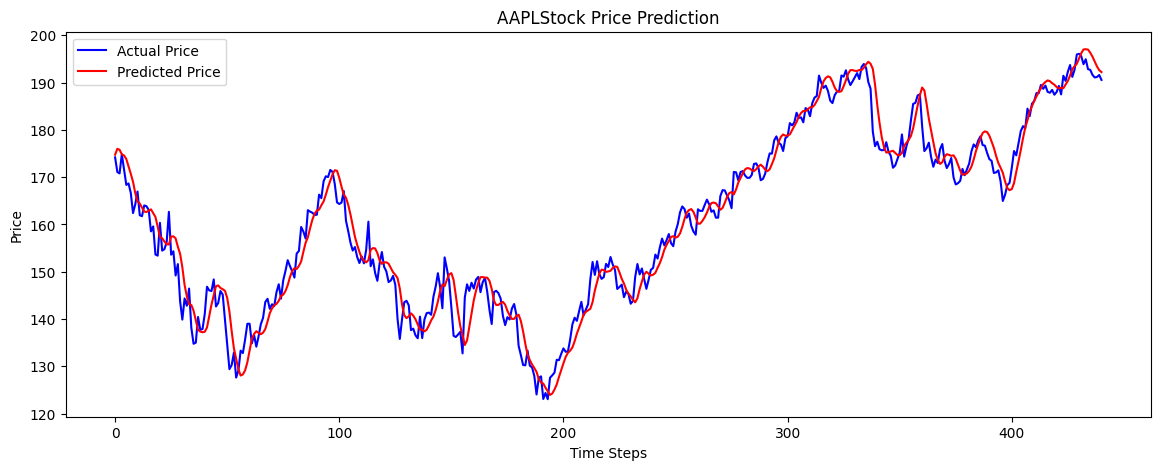

In [43]:
# 시각화
plt.figure(figsize=(14,5))
plt.plot(actual_prices, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red')
plt.title(f'{ticker}Stock Price Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()

In [46]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [47]:
# 데이터 불러오기
data_path = 'dataset/airline.csv'  # 데이터 경로
df = pd.read_csv(data_path)

In [48]:
# 데이터 확인
print(df.head())

         date  count
0  1949-01-01    112
1  1949-02-01    118
2  1949-03-01    132
3  1949-04-01    129
4  1949-05-01    121


In [50]:
# 날짜(Date)와 탑승객 수 (count) 열의 이름 설정 및 변환
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

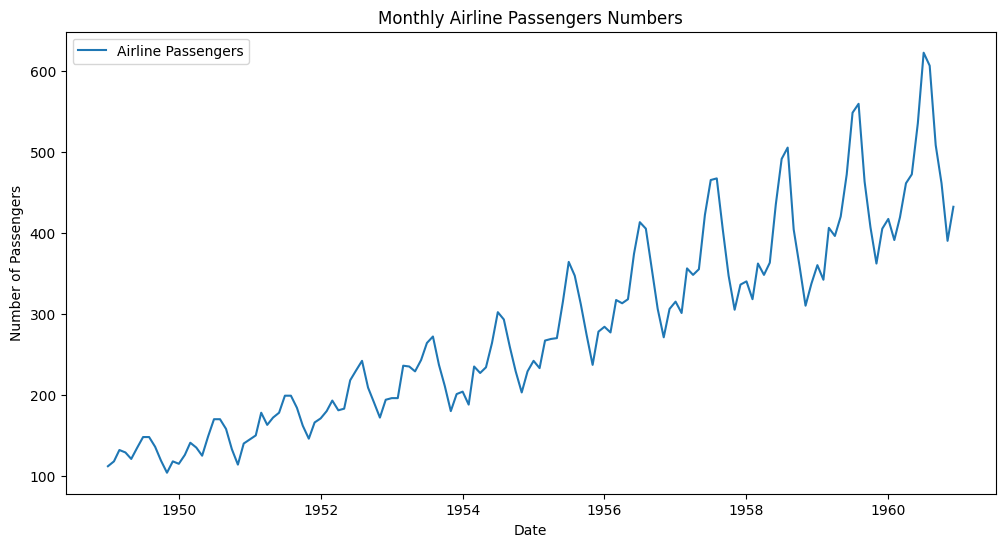

In [51]:
# 데이터 시각화
plt.figure(figsize=(12,6))
plt.plot(df['count'], label='Airline Passengers')
plt.title('Monthly Airline Passengers Numbers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [54]:
# 데이터 정규화
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df[['count']])

In [55]:
# 데이터셋 분리 (학습 데이터와 테스트 데이터)
train_size= int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [56]:
# 시계열 데이터셋 생성 함수
def create_dataset(data, time_step=12) :
    X, y = [], []
    for i in range(len(data) - time_step) :
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

In [57]:
time_step = 12 # 12개월 단위로 예측
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [58]:
# LSTM 입력에 맞게 데이터 형태 변경
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [59]:
# LSTM 모델 생성
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(time_step, 1)),
    LSTM(32, return_sequences=False),
    Dense(25),
    Dense(1)
])


d:\python_sim\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [60]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

In [61]:
# 모델 학습
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, shuffle=False, verbose=1)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 63s 170ms/step - loss: 0.0830 - val_loss: 0.2535
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0238 - val_loss: 0.0729
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0086 - val_loss: 0.0228
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0224 - val_loss: 0.0231
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0155 - val_loss: 0.0388
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0111 - val_loss: 0.0590
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0105 - val_loss: 0.0545
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0085 - val_loss: 0.0369
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0077 - val_loss: 0.0262
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0085 - val_loss: 0.0247
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0080 - val_loss: 0.0267
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0071 - val_loss: 0.0296

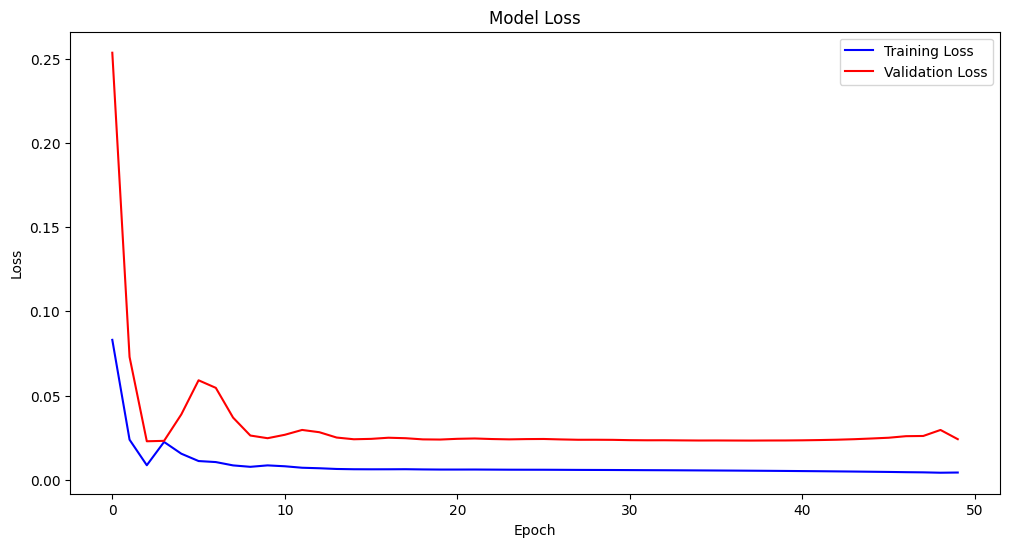

In [62]:
# 학습 과정 시각화
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [63]:
# 테스트 데이터 예측
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [64]:
# 예측값 역정규화
train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform(y_train.reshape(-1,1))
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform(y_test.reshape(-1,1))

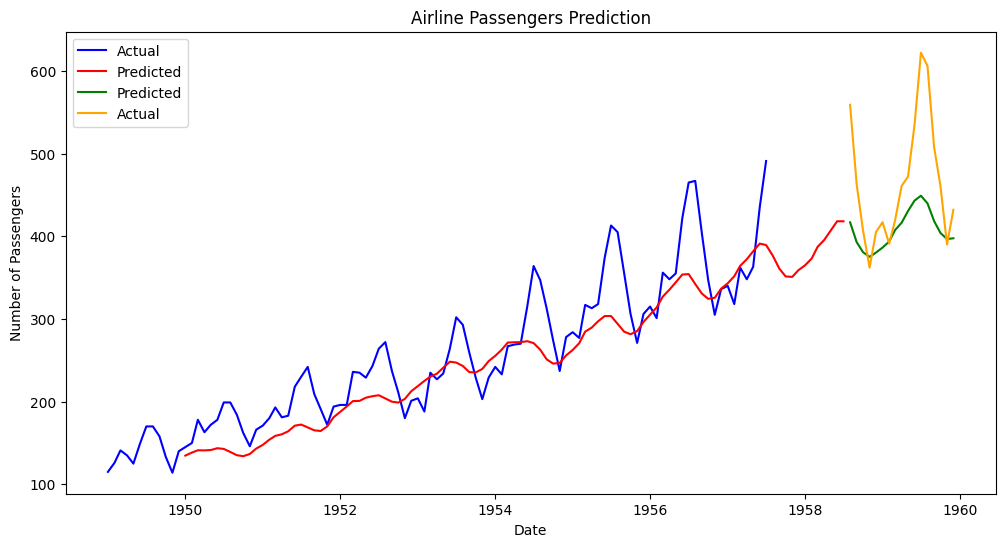

In [69]:
# 예측 결과 시각화
plt.figure(figsize=(12,6))
plt.plot(df.index[:len(y_train)], y_train, label='Actual', color='blue')
plt.plot(df.index[time_step:len(train_predict) + time_step], train_predict, label='Predicted', color='red')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], test_predict, label='Predicted', color='green')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], y_test, label='Actual', color='orange')
plt.title('Airline Passengers Prediction')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()